In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")

In [3]:
import pandas as pd

df = train.copy()

# Drop ID
df = df.drop(columns=["Employee ID"])

# Convert date and create days_since_joined
df["Date of Joining"] = pd.to_datetime(df["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df["days_since_joined"] = (reference_date - df["Date of Joining"]).dt.days
df = df.drop(columns=["Date of Joining"])

# Binary encoding
df["gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["company_type"] = df["Company Type"].map({"Service": 1, "Product": 0})
df["is_wfh"] = df["WFH Setup Available"].map({"Yes": 1, "No": 0})

df = df.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

print(df.head())

   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0            2                  3.0                   3.8       0.16   
1            1                  2.0                   5.0       0.36   
2            2                  NaN                   5.8       0.49   
3            1                  1.0                   2.6       0.20   
4            3                  7.0                   6.9       0.52   

   days_since_joined  gender  company_type  is_wfh  
0                 92       0             1       0  
1                 31       1             1       1  
2                296       0             0       1  
3                 58       1             1       1  
4                160       0             1       0  


In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
# Start from raw dataframe
df_clean = train.copy()

# Drop Employee ID
df_clean = df_clean.drop(columns=["Employee ID"])

# Convert Date of Joining to days_since_joined using 2008-12-31 as reference
df_clean["Date of Joining"] = pd.to_datetime(df_clean["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df_clean["days_since_joined"] = (reference_date - df_clean["Date of Joining"]).dt.days
df_clean = df_clean.drop(columns=["Date of Joining"])

# Binary encoding
# gender: Male = 1, Female = 0
# company_type: Service = 1, Product = 0
# is_wfh: Yes = 1, No = 0
df_clean["gender"] = df_clean["Gender"].map({"Male": 1, "Female": 0})
df_clean["company_type"] = df_clean["Company Type"].map({"Service": 1, "Product": 0})
df_clean["is_wfh"] = df_clean["WFH Setup Available"].map({"Yes": 1, "No": 0})

df_clean = df_clean.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

# Columns to impute
cols_to_impute = ["Mental Fatigue Score", "Resource Allocation"]

# Continuous columns to scale
scale_cols = ["Designation", "Resource Allocation", "Mental Fatigue Score", "days_since_joined"]

# -----------------------------
# Median-imputed + scaled dataset
# -----------------------------
df_median = df_clean.copy()
for col in cols_to_impute:
    df_median[col] = df_median[col].fillna(df_median[col].median())

scaler_median = StandardScaler()
df_median[scale_cols] = scaler_median.fit_transform(df_median[scale_cols])

# -----------------------------
# Empirical probabilistic-imputed + scaled dataset
# -----------------------------
df_prob = df_clean.copy()
rng = np.random.default_rng(42)

for col in cols_to_impute:
    missing_mask = df_prob[col].isna()
    observed_values = df_prob.loc[~missing_mask, col].values
    df_prob.loc[missing_mask, col] = rng.choice(
        observed_values,
        size=missing_mask.sum(),
        replace=True
    )

scaler_prob = StandardScaler()
df_prob[scale_cols] = scaler_prob.fit_transform(df_prob[scale_cols])

print("Median-imputed + scaled dataset preview:")
print(df_median.head())

print("\nProbabilistic-imputed + scaled dataset preview:")
print(df_prob.head())

Median-imputed + scaled dataset preview:
   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0    -0.157451            -0.730698             -1.062437       0.16   
1    -1.038415            -1.233872             -0.406671       0.36   
2    -0.157451            -0.227523              0.030506       0.49   
3    -1.038415            -1.737046             -1.718203       0.20   
4     0.723514             1.282000              0.631625       0.52   

   days_since_joined  gender  company_type  is_wfh  
0          -0.860076       0             1       0  
1          -1.439121       1             1       1  
2           1.076402       0             0       1  
3          -1.182823       1             1       1  
4          -0.214584       0             1       0  

Probabilistic-imputed + scaled dataset preview:
   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0    -0.157451            -0.722391             -1.002314       0.16   
1    -1.038415 

In [6]:
df_median

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh
0,-0.157451,-0.730698,-1.062437,0.16,-0.860076,0,1,0
1,-1.038415,-1.233872,-0.406671,0.36,-1.439121,1,1,1
2,-0.157451,-0.227523,0.030506,0.49,1.076402,0,0,1
3,-1.038415,-1.737046,-1.718203,0.20,-1.182823,1,1,1
4,0.723514,1.282000,0.631625,0.52,-0.214584,0,1,0
...,...,...,...,...,...,...,...,...
22745,-1.038415,-0.730698,0.085153,0.41,-1.723898,0,1,0
22746,0.723514,0.778825,0.522331,0.59,1.560522,0,0,1
22747,0.723514,1.282000,0.085153,0.72,-1.201808,1,1,1
22748,-0.157451,0.275651,0.085153,0.52,1.645954,0,1,0


*Drop na records from df_median and df_prob***

In [7]:
df_median = df_median.dropna()

In [8]:
df_median 

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh
0,-0.157451,-0.730698,-1.062437,0.16,-0.860076,0,1,0
1,-1.038415,-1.233872,-0.406671,0.36,-1.439121,1,1,1
2,-0.157451,-0.227523,0.030506,0.49,1.076402,0,0,1
3,-1.038415,-1.737046,-1.718203,0.20,-1.182823,1,1,1
4,0.723514,1.282000,0.631625,0.52,-0.214584,0,1,0
...,...,...,...,...,...,...,...,...
22745,-1.038415,-0.730698,0.085153,0.41,-1.723898,0,1,0
22746,0.723514,0.778825,0.522331,0.59,1.560522,0,0,1
22747,0.723514,1.282000,0.085153,0.72,-1.201808,1,1,1
22748,-0.157451,0.275651,0.085153,0.52,1.645954,0,1,0


In [9]:
df_prob = df_prob.dropna()
df_prob

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh
0,-0.157451,-0.722391,-1.002314,0.16,-0.860076,0,1,0
1,-1.038415,-1.210494,-0.377628,0.36,-1.439121,1,1,1
2,-0.157451,-1.210494,0.038829,0.49,1.076402,0,0,1
3,-1.038415,-1.698596,-1.627000,0.20,-1.182823,1,1,1
4,0.723514,1.230018,0.611458,0.52,-0.214584,0,1,0
...,...,...,...,...,...,...,...,...
22745,-1.038415,-0.722391,1.912886,0.41,-1.723898,0,1,0
22746,0.723514,0.741915,0.507343,0.59,1.560522,0,0,1
22747,0.723514,1.230018,-0.794085,0.72,-1.201808,1,1,1
22748,-0.157451,0.253813,0.090886,0.52,1.645954,0,1,0


**Remove outliers from df_median and df prob**

In [10]:
numerics1 = df_median[["Resource Allocation", "Mental Fatigue Score", "Burn Rate"]]

q1 = numerics1.quantile(0.25)
q3 = numerics1.quantile(0.75)
iqr_vals = q3 - q1

mask = ~((numerics1 < (q1 - 1.5 * iqr_vals)) | (numerics1 > (q3 + 1.5 * iqr_vals))).any(axis=1)
df_median = df_median[mask]

print(df_median.shape)

(21144, 8)


In [11]:
numerics2 = df_prob[["Resource Allocation", "Mental Fatigue Score", "Burn Rate"]]

q1 = numerics2.quantile(0.25)
q3 = numerics2.quantile(0.75)
iqr_vals = q3 - q1

mask = ~((numerics2 < (q1 - 1.5 * iqr_vals)) | (numerics2 > (q3 + 1.5 * iqr_vals))).any(axis=1)
df_prob = df_prob[mask]

print(df_prob.shape)

(21266, 8)


**Perform Gradient Boosting Baseline Model with df_median**

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform
import numpy as np
import pandas as pd

In [13]:
features = [
    "gender",
    "Designation",
    "company_type",
    "is_wfh",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

In [14]:
X = df_median[features]
Y = df_median["Burn Rate"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [16]:
categorical_columns = [
    "gender",
    "company_type",
    "is_wfh"
]

In [17]:
numerical_columns = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

In [18]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [19]:
preprocessed = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_columns),
        ("num", "passthrough", numerical_columns)
    ]
)

In [20]:
X_train_processed = preprocessed.fit_transform(X_train)
X_test_processed = preprocessed.transform(X_test)

In [21]:
params = {
    "n_estimators":500,
    "max_depth":4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error"
}

In [22]:
from sklearn import ensemble
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train_processed, Y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [23]:
y_pred = reg.predict(X_test_processed)

In [24]:
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Results for Gradient Boosted Baseline Model")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Results for Gradient Boosted Baseline Model
RMSE: 0.0623
MAE:  0.0488
R²:   0.8905


In [25]:
feature_names = preprocessed.get_feature_names_out()
feat_importances = pd.Series(reg.feature_importances_, index=preprocessed.get_feature_names_out())

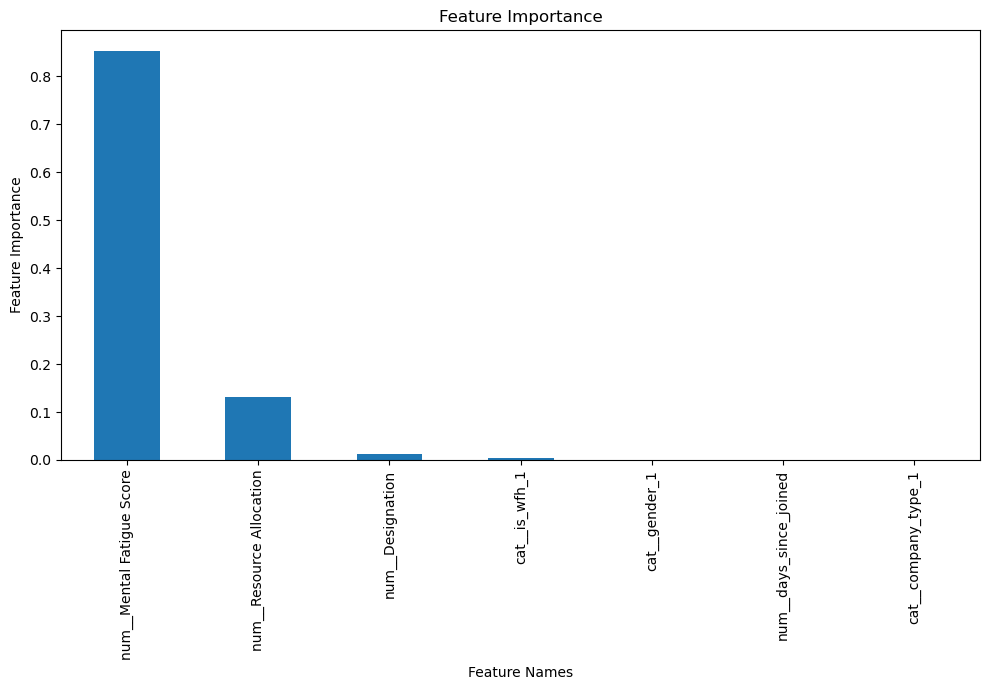

In [26]:
feat_importances.nlargest(20).plot(kind="bar", figsize=(10, 7))
plt.title("Feature Importance")
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.show()

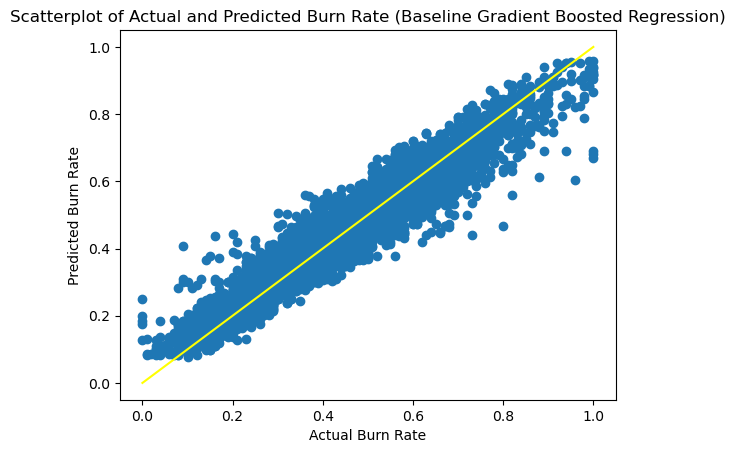

In [27]:
plt.scatter(Y_test, y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color="yellow")
plt.title("Scatterplot of Actual and Predicted Burn Rate (Baseline Gradient Boosted Regression)")
plt.xlabel("Actual Burn Rate")
plt.ylabel("Predicted Burn Rate")
plt.show()

**Fit Optimized Model with five k fold validation**

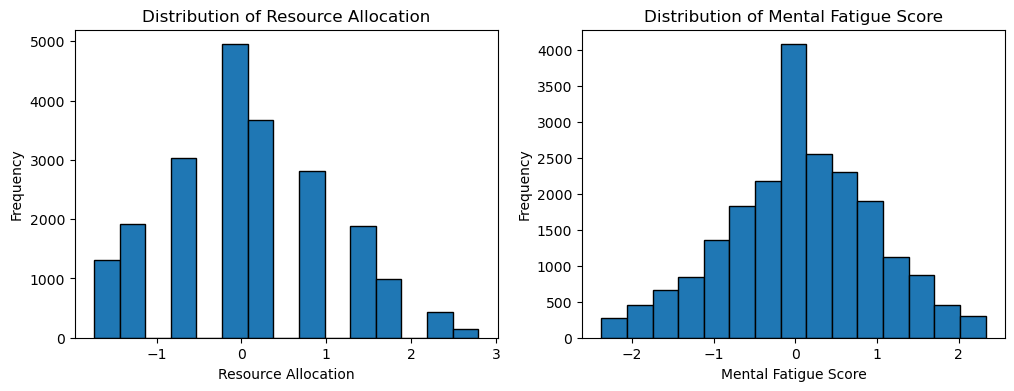

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_median["Resource Allocation"], bins=15, edgecolor="black")
axes[0].set_title("Distribution of Resource Allocation")
axes[0].set_xlabel("Resource Allocation")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_median["Mental Fatigue Score"], bins=15, edgecolor="black")
axes[1].set_title("Distribution of Mental Fatigue Score")
axes[1].set_xlabel("Mental Fatigue Score")
axes[1].set_ylabel("Frequency")
plt.show()

In [30]:
print(f"Resource Allocation skew:   {df_median['Resource Allocation'].skew():.4f}")
print(f"Mental Fatigue Score skew:  {df_median['Mental Fatigue Score'].skew():.4f}")

Resource Allocation skew:   0.2682
Mental Fatigue Score skew:  -0.1455


In [31]:
features1 = ["Mental Fatigue Score", "Resource Allocation"]

In [32]:
X = df_median[features1]
Y = df_median["Burn Rate"]

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [34]:
pipe = Pipeline([
    ("pre", ColumnTransformer([("num", "passthrough", features1)])),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [35]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
base_params = {
    "model__n_estimators":      500,
    "model__max_depth":         4,
    "model__min_samples_split": 5,
    "model__learning_rate":     0.01,
    "model__loss":              "squared_error"
}
pipe.set_params(**base_params)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,

In [37]:
cv = cross_validate(pipe, X_train, Y_train, cv=kf, scoring={
    "RMSE": "neg_root_mean_squared_error",
    "MAE":  "neg_mean_absolute_error",
    "R2":   "r2"
})

cv_rmse = -cv["test_RMSE"].mean()
cv_mae  = -cv["test_MAE"].mean()
cv_r2   =  cv["test_R2"].mean()

In [38]:
param_dist = {
    "model__n_estimators":      randint(300, 700),
    "model__max_depth":         randint(3, 7),
    "model__min_samples_split": randint(2, 10),
    "model__learning_rate":     uniform(0.005, 0.05),
    "model__subsample":         uniform(0.7, 0.3),
    "model__max_features":      ["sqrt", "log2", None]
}

In [39]:
rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs.fit(X_train, Y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': <scipy.stats....0017374B732F0>, 'model__max_depth': <scipy.stats....0017374B722A0>, 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_split': <scipy.stats....0017374B72840>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the 

In [40]:
y_pred_tuned = rs.best_estimator_.predict(X_test)
rs_rmse = np.sqrt(mean_squared_error(Y_test, y_pred_tuned))
rs_mae  = mean_absolute_error(Y_test, y_pred_tuned)
rs_r2   = r2_score(Y_test, y_pred_tuned)

In [41]:
summary = pd.DataFrame({
    "K-Fold CV":              [cv_rmse, cv_mae, cv_r2],
    "Randomized Grid Search": [rs_rmse, rs_mae, rs_r2]
}, index=["RMSE", "MAE", "R²"])

print("Gradient Boosting — K-Fold CV vs Randomized Grid Search")
print(summary.round(4).to_string())

print(f"\nBest Params:")
for k, v in rs.best_params_.items():
    print(f"  {k}: {v}")

Gradient Boosting — K-Fold CV vs Randomized Grid Search
      K-Fold CV  Randomized Grid Search
RMSE     0.0639                  0.0639
MAE      0.0500                  0.0499
R²       0.8864                  0.8849

Best Params:
  model__learning_rate: 0.04577307142274171
  model__max_depth: 3
  model__max_features: None
  model__min_samples_split: 4
  model__n_estimators: 588
  model__subsample: 0.8817879924343034


**Baseline Model for decision tree**

In [52]:
features2 = [
    "gender",
    "Designation",
    "company_type",
    "is_wfh",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

In [53]:
X = df_median[features2]
Y = df_median["Burn Rate"]

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [55]:
categorical_columns = [
    "gender",
    "company_type",
    "is_wfh"
]

In [56]:
numerical_columns = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

In [57]:
preprocessed = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_columns),
        ("num", "passthrough", numerical_columns)
    ]
)

In [58]:
X_train_processed = preprocessed.fit_transform(X_train)
X_test_processed = preprocessed.transform(X_test)

In [59]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor.fit(X_train_processed, Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [60]:
y_pred = regressor.predict(X_test_processed)

In [61]:
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Results for Baseline Decision Tree Model")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Results for Baseline Decision Tree Model
RMSE: 0.0756
MAE:  0.0582
R²:   0.8386


In [103]:
feature_names = preprocessed.get_feature_names_out()
feat_importances = pd.Series(reg.feature_importances_, index=preprocessed.get_feature_names_out())

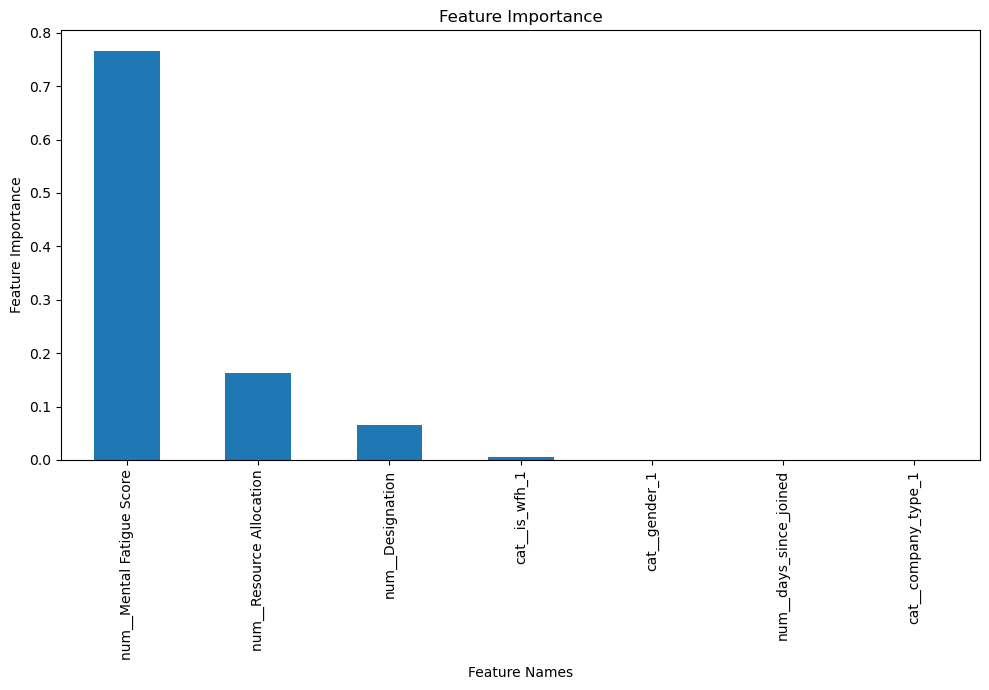

In [104]:
feat_importances.nlargest(20).plot(kind="bar", figsize=(10, 7))
plt.title("Feature Importance")
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.show()

**Develop a decision tree for k-fold cross-validation as well as randomized grid search**

In [106]:
features3 = ["Mental Fatigue Score", "Resource Allocation", "Designation"]

In [107]:
X = df_median[features3]
Y = df_median["Burn Rate"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, shuffle=True, random_state=42
)

In [108]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features3)
    ]
)

In [109]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [110]:
pipe_dt = Pipeline([
    ("pre",   preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [111]:
#Step 1: K-Fold CV
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE":  "neg_mean_absolute_error",
    "R2":   "r2"
}

cv = cross_validate(pipe_dt, X_train, Y_train, cv=kf, scoring=scoring)

cv_rmse = -cv["test_RMSE"].mean()
cv_mae  = -cv["test_MAE"].mean()
cv_r2   =  cv["test_R2"].mean()

In [112]:
param_dist = {
    "model__max_depth":         randint(3, 20),
    "model__min_samples_split": randint(2, 50),
    "model__min_samples_leaf":  randint(1, 30),
    "model__max_features":      ["sqrt", "log2", None],
    "model__ccp_alpha":         uniform(0.0, 0.02)
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__ccp_alpha': <scipy.stats....0017376BBB9B0>, 'model__max_depth': <scipy.stats....0017376BB8290>, 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....00173769468A0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same

In [113]:
y_pred_tuned = rs.best_estimator_.predict(X_test)
rs_rmse = np.sqrt(mean_squared_error(Y_test, y_pred_tuned))
rs_mae  = mean_absolute_error(Y_test, y_pred_tuned)
rs_r2   = r2_score(Y_test, y_pred_tuned)

In [114]:
summary = pd.DataFrame({
    "K-Fold CV":              [cv_rmse, cv_mae, cv_r2],
    "Randomized Grid Search": [rs_rmse, rs_mae, rs_r2]
}, index=["RMSE", "MAE", "R²"])

print("Decision Tree — K-Fold CV vs Randomized Grid Search")
print("Features: Mental Fatigue Score, Resource Allocation")
print(summary.round(4).to_string())

print(f"\nBest Params:")
for k, v in rs.best_params_.items():
    print(f"  {k}: {v}")

Decision Tree — K-Fold CV vs Randomized Grid Search
Features: Mental Fatigue Score, Resource Allocation
      K-Fold CV  Randomized Grid Search
RMSE     0.0631                  0.0763
MAE      0.0496                  0.0579
R²       0.8892                  0.8357

Best Params:
  model__ccp_alpha: 0.000306090805807695
  model__max_depth: 3
  model__max_features: sqrt
  model__min_samples_leaf: 13
  model__min_samples_split: 5


**Perform the baseline model for gradient boosting but for df_prob**

In [74]:
features = [
    "gender",
    "Designation",
    "company_type",
    "is_wfh",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

X = df_prob[features]
Y = df_prob["Burn Rate"]

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [75]:
categorical_columns = [
    "gender",
    "company_type",
    "is_wfh"
]

numerical_columns = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

In [76]:
preprocessed = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_columns),
        ("num", "passthrough", numerical_columns)
    ]
)

X_train_processed = preprocessed.fit_transform(X_train)
X_test_processed = preprocessed.transform(X_test)

In [77]:
params = {
    "n_estimators":500,
    "max_depth":4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error"
}

In [78]:
from sklearn import ensemble
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train_processed, Y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [79]:
y_pred = reg.predict(X_test_processed)

rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Results for Gradient Boosted Baseline Model")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Results for Gradient Boosted Baseline Model
RMSE: 0.0723
MAE:  0.0541
R²:   0.8563


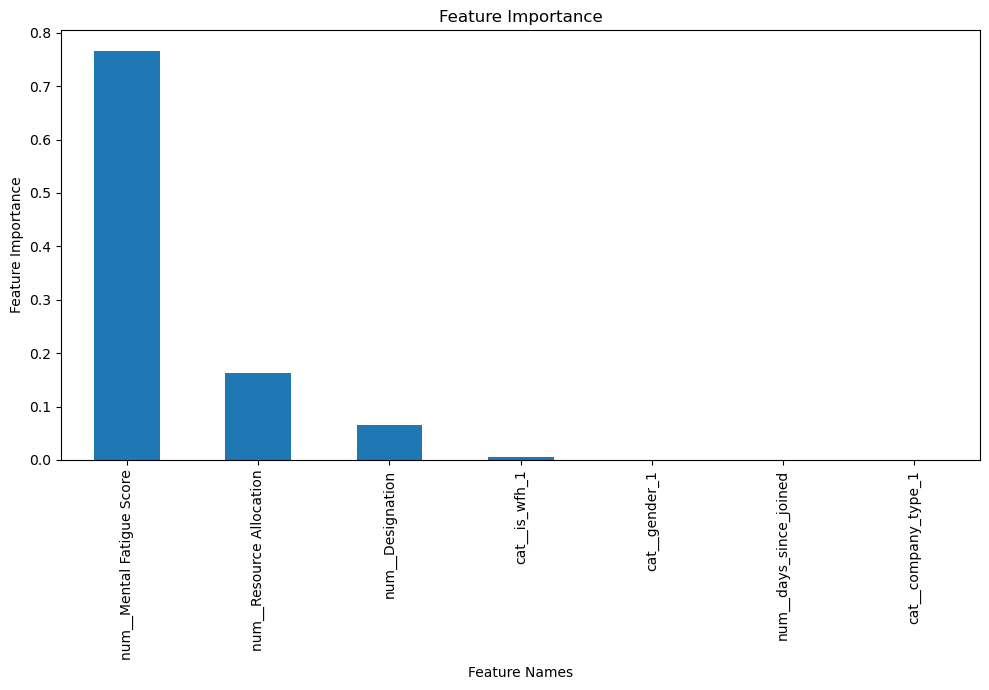

In [80]:
feature_names = preprocessed.get_feature_names_out()
feat_importances = pd.Series(reg.feature_importances_, index=preprocessed.get_feature_names_out())

feat_importances.nlargest(20).plot(kind="bar", figsize=(10, 7))
plt.title("Feature Importance")
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.show()

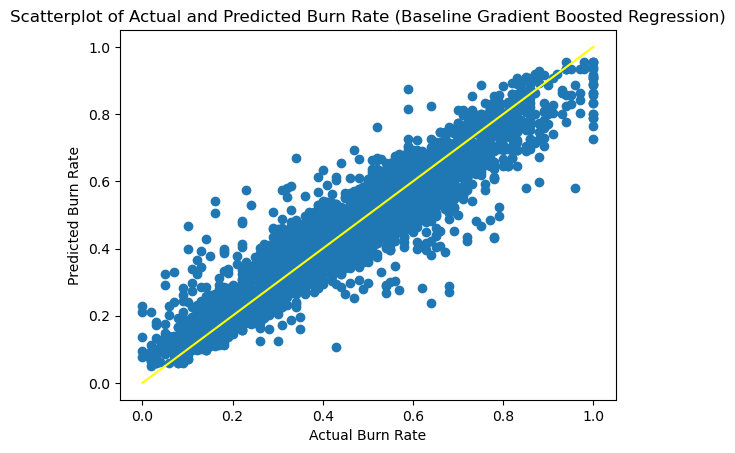

In [81]:
plt.scatter(Y_test, y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color="yellow")
plt.title("Scatterplot of Actual and Predicted Burn Rate (Baseline Gradient Boosted Regression)")
plt.xlabel("Actual Burn Rate")
plt.ylabel("Predicted Burn Rate")
plt.show()

**Perform the kfold cross validation and randomized grid search for gradient boosting but for df_prob**

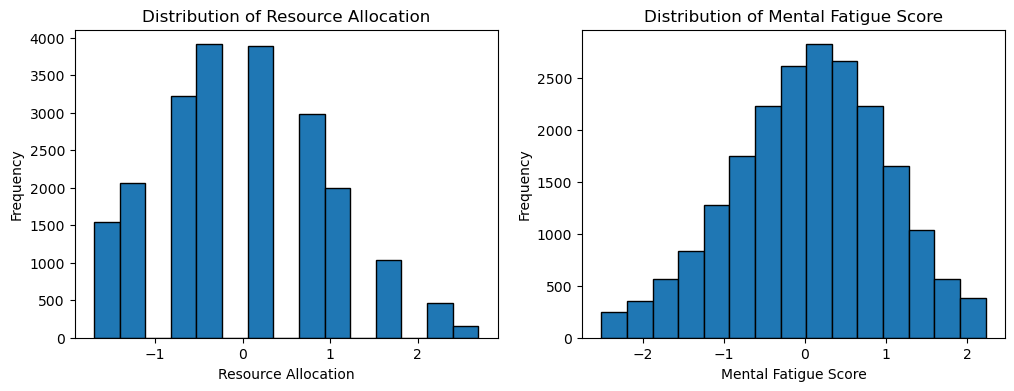

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_prob["Resource Allocation"], bins=15, edgecolor="black")
axes[0].set_title("Distribution of Resource Allocation")
axes[0].set_xlabel("Resource Allocation")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_prob["Mental Fatigue Score"], bins=15, edgecolor="black")
axes[1].set_title("Distribution of Mental Fatigue Score")
axes[1].set_xlabel("Mental Fatigue Score")
axes[1].set_ylabel("Frequency")

plt.show()

In [88]:
features4 = ["Mental Fatigue Score", "Resource Allocation", "Designation"]

X = df_prob[features4]
Y = df_prob["Burn Rate"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [89]:
pipe = Pipeline([
    ("pre", ColumnTransformer([("num", "passthrough", features1)])),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [90]:
base_params = {
    "model__n_estimators":      500,
    "model__max_depth":         4,
    "model__min_samples_split": 5,
    "model__learning_rate":     0.01,
    "model__loss":              "squared_error"
}
pipe.set_params(**base_params)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,

In [91]:
cv = cross_validate(pipe, X_train, Y_train, cv=kf, scoring={
    "RMSE": "neg_root_mean_squared_error",
    "MAE":  "neg_mean_absolute_error",
    "R2":   "r2"
})

cv_rmse = -cv["test_RMSE"].mean()
cv_mae  = -cv["test_MAE"].mean()
cv_r2   =  cv["test_R2"].mean()

In [92]:
param_dist = {
    "model__n_estimators":      randint(300, 700),
    "model__max_depth":         randint(3, 7),
    "model__min_samples_split": randint(2, 10),
    "model__learning_rate":     uniform(0.005, 0.05),
    "model__subsample":         uniform(0.7, 0.3),
    "model__max_features":      ["sqrt", "log2", None]
}

In [93]:
rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs.fit(X_train, Y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': <scipy.stats....0017374B73890>, 'model__max_depth': <scipy.stats....0017374B6FA10>, 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_split': <scipy.stats....00173769050A0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the 

In [94]:
y_pred_tuned = rs.best_estimator_.predict(X_test)
rs_rmse = np.sqrt(mean_squared_error(Y_test, y_pred_tuned))
rs_mae  = mean_absolute_error(Y_test, y_pred_tuned)
rs_r2   = r2_score(Y_test, y_pred_tuned)

In [95]:
summary = pd.DataFrame({
    "K-Fold CV":              [cv_rmse, cv_mae, cv_r2],
    "Randomized Grid Search": [rs_rmse, rs_mae, rs_r2]
}, index=["RMSE", "MAE", "R²"])

print("Gradient Boosting — K-Fold CV vs Randomized Grid Search")
print(summary.round(4).to_string())

print(f"\nBest Params:")
for k, v in rs.best_params_.items():
    print(f"  {k}: {v}")

Gradient Boosting — K-Fold CV vs Randomized Grid Search
      K-Fold CV  Randomized Grid Search
RMSE     0.0788                  0.0827
MAE      0.0566                  0.0590
R²       0.8316                  0.8119

Best Params:
  model__learning_rate: 0.013061064362700221
  model__max_depth: 4
  model__max_features: log2
  model__min_samples_split: 6
  model__n_estimators: 361
  model__subsample: 0.890021126953127


**Perform the baseline model for decision tree for df_prob**

In [96]:
features5 = [
    "gender",
    "Designation",
    "company_type",
    "is_wfh",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

X = df_prob[features5]
Y = df_prob["Burn Rate"]

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [97]:
categorical_columns = [
    "gender",
    "company_type",
    "is_wfh"
]

numerical_columns = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

In [99]:
preprocessed = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_columns),
        ("num", "passthrough", numerical_columns)
    ]
)

X_train_processed = preprocessed.fit_transform(X_train)
X_test_processed = preprocessed.transform(X_test)

In [100]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor.fit(X_train_processed, Y_train)

y_pred = regressor.predict(X_test_processed)

In [101]:
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("Results for Baseline Decision Tree Model")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Results for Baseline Decision Tree Model
RMSE: 0.0869
MAE:  0.0644
R²:   0.7923


In [ ]:
feature_names = preprocessed.get_feature_names_out()
feat_importances = pd.Series(reg.feature_importances_, index=preprocessed.get_feature_names_out())

In [ ]:
feat_importances.nlargest(20).plot(kind="bar", figsize=(10, 7))
plt.title("Feature Importance")
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.show()

**Perform the kfold cross-validation and randomized grid search for df_prob**

In [115]:
features6 = ["Mental Fatigue Score", "Resource Allocation", "Designation"]

X = df_prob[features6]
Y = df_prob["Burn Rate"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, shuffle=True, random_state=42
)

In [116]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features6)
    ]
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

pipe_dt = Pipeline([
    ("pre",   preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [117]:
#Step 1: K-Fold CV
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE":  "neg_mean_absolute_error",
    "R2":   "r2"
}

cv = cross_validate(pipe_dt, X_train, Y_train, cv=kf, scoring=scoring)

cv_rmse = -cv["test_RMSE"].mean()
cv_mae  = -cv["test_MAE"].mean()
cv_r2   =  cv["test_R2"].mean()

In [118]:
param_dist = {
    "model__max_depth":         randint(3, 20),
    "model__min_samples_split": randint(2, 50),
    "model__min_samples_leaf":  randint(1, 30),
    "model__max_features":      ["sqrt", "log2", None],
    "model__ccp_alpha":         uniform(0.0, 0.02)
}

In [119]:
rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__ccp_alpha': <scipy.stats....0017376907680>, 'model__max_depth': <scipy.stats....0017374C09B50>, 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....001737455B950>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same

In [120]:
y_pred_tuned = rs.best_estimator_.predict(X_test)
rs_rmse = np.sqrt(mean_squared_error(Y_test, y_pred_tuned))
rs_mae  = mean_absolute_error(Y_test, y_pred_tuned)
rs_r2   = r2_score(Y_test, y_pred_tuned)

In [121]:
summary = pd.DataFrame({
    "K-Fold CV":              [cv_rmse, cv_mae, cv_r2],
    "Randomized Grid Search": [rs_rmse, rs_mae, rs_r2]
}, index=["RMSE", "MAE", "R²"])

print("Decision Tree — K-Fold CV vs Randomized Grid Search")
print("Features: Mental Fatigue Score, Resource Allocation")
print(summary.round(4).to_string())

print(f"\nBest Params:")
for k, v in rs.best_params_.items():
    print(f"  {k}: {v}")

Decision Tree — K-Fold CV vs Randomized Grid Search
Features: Mental Fatigue Score, Resource Allocation
      K-Fold CV  Randomized Grid Search
RMSE     0.0751                  0.0889
MAE      0.0549                  0.0647
R²       0.8472                  0.7828

Best Params:
  model__ccp_alpha: 0.000306090805807695
  model__max_depth: 3
  model__max_features: sqrt
  model__min_samples_leaf: 13
  model__min_samples_split: 5
